# Parallelization

With parallelization, LLMs work simultaneously on a task. This is either done by running multiple independent subtasks at the same time, or running the same task multiple times to check for different outputs. Parallelization is commonly used to:

* Split up subtasks and run them in parallel, which increases speed
* Run tasks multiple times to check for different outputs, which increases confidence

Some examples include:

* Running one subtask that processes a document for keywords, and a second subtask to check for formatting errors
* Running a task multiple times that scores a document for accuracy based on different criteria, like the number of citations, the number of sources used, and the quality of the sources

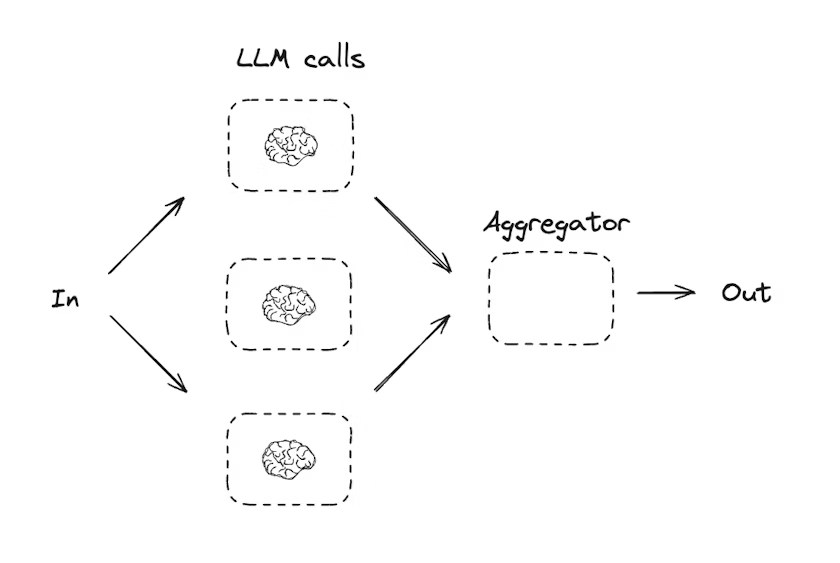

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")

from langchain.chat_models import init_chat_model

llm = init_chat_model("claude-haiku-4-5", temperature=0, max_tokens=100)

## By using Graph API

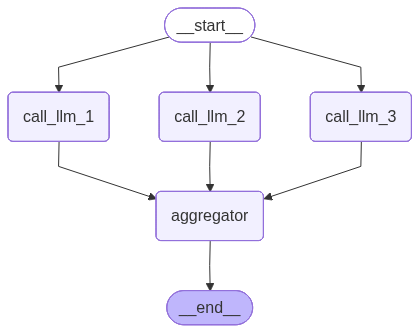

Here's a story, joke, and poem about computers!

STORY:
# The Last Keystroke

The old computer sat in the corner of Marcus's repair shop like a patient dog waiting to be noticed.

It had been there for three weeks, dropped off by a woman named Eleanor who said it belonged to her late husband. She didn't want it fixed, exactly. She just wanted to know if anything could be saved from the hard drive before she donated the machine to charity.

Marcus had been meaning to get to it. He always meant to get to

JOKE:
Here's one:

**Why did the computer go to the doctor?**

Because it had a *virus* and wouldn't stop *coughing up* error messages! 😄

---

Or a classic:

**Why do programmers prefer dark mode?**

Because light attracts *bugs*! 🐛

POEM:
# The Thinking Machine

A box of light upon my desk,
A humming, glowing thing,
With circuits wired like spider webs
And fans that softly sing.

It holds a billion whispered words,
A universe of code,
Where numbers dance like fireflies
Along a silver 

In [5]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = parallel_workflow.invoke({"topic": "computers"})
print(state["combined_output"])

## By using Functional API

In [6]:
from langgraph.func import entrypoint, task

@task
def call_llm_1(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a joke about {topic}")
    return msg.content


@task
def call_llm_2(topic: str):
    """Second LLM call to generate story"""
    msg = llm.invoke(f"Write a story about {topic}")
    return msg.content


@task
def call_llm_3(topic):
    """Third LLM call to generate poem"""
    msg = llm.invoke(f"Write a poem about {topic}")
    return msg.content


@task
def aggregator(topic, joke, story, poem):
    """Combine the joke and story into a single output"""

    combined = f"Here's a story, joke, and poem about {topic}!\n\n"
    combined += f"STORY:\n{story}\n\n"
    combined += f"JOKE:\n{joke}\n\n"
    combined += f"POEM:\n{poem}"
    return combined


# Build workflow
@entrypoint()
def parallel_workflow(topic: str):
    joke_fut = call_llm_1(topic)
    story_fut = call_llm_2(topic)
    poem_fut = call_llm_3(topic)
    return aggregator(
        topic, joke_fut.result(), story_fut.result(), poem_fut.result()
    ).result()


# Invoke
for step in parallel_workflow.stream("cats", stream_mode="updates"):
    print(step)
    print("\n")

{'call_llm_1': "Here's one:\n\n**Why don't cats play poker in the jungle?**\n\nToo many cheetahs. 🐱\n\n*(Okay, the cheetah's not technically a cat... but your cat would still judge you for laughing.)* 😄"}


{'call_llm_2': "# The Midnight Council\n\nThe old oak tree in Mrs. Pemberton's backyard had been the meeting place for as long as any cat in the neighborhood could remember.\n\nEvery full moon, they came.\n\n---\n\nJasper arrived first, as he always did. He was a large orange tabby with a torn ear and the kind of confidence that only comes from surviving seven winters on your own. He leaped onto the lowest branch and settled himself with practiced ease,"}


{'call_llm_3': "# Cats\n\nThey move like liquid through the room,\nA shadow slipping past the door,\nThey own the silence, own the gloom,\nAnd every inch of every floor.\n\nWith velvet paws and ancient eyes,\nThat hold the secrets of the night,\nThey watch the world with cool surprise,\nThen vanish softly from your sight.\n\nThey